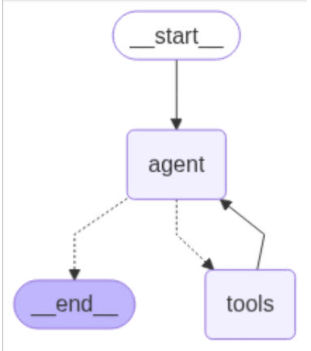

- 注意：智能体的本质是什么？
    - 本质就是由“大模型+外部工具+提示词”组成的！ 

In [1]:
!python -V

Python 3.12.3


In [2]:
from typing import Literal
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END,StateGraph,MessagesState
from langgraph.prebuilt import ToolNode

In [3]:
#定义智能体可以被调用的外部函数
@tool
def search(query:str):
    """模拟一个气象查询搜索工具"""
    if "北京" in query.lower() or "Beijing" in query.lower():
        return "阴天有雾，气温25度"
    return "天气晴朗温度较高39度"

In [4]:
#将外部函数/工具存放在工具箱中
tools = [search]

In [5]:
#创建预定义工具节点
tool_node = ToolNode(tools)

In [6]:
#定义大模型对象
API_KEY = "xxxx"
model = ChatOpenAI(model_name="deepseek-chat",
                  api_key=API_KEY,base_url="https://api.deepseek.com")

In [7]:
#将工具箱绑定到大模型对象中，使得模型具备外部工具调用的能力
model = model.bind_tools(tools)

In [8]:
#定义一个新的空白图结构(带状态的图结构)
workflow = StateGraph(MessagesState)

In [9]:
#在空白图结构中进行节点添加
    #add_node:参数1表示节点名字（可自定义）
workflow.add_node('tools',tool_node)

In [10]:
#定义一个模型调用的函数
def call_model(state:MessagesState):
    # print("agent节点被调用时对应的state：",state)
    #获取消息列表
    messages = state['messages']
    #调用模型返回结果
    response = model.invoke(messages)
    return {"messages":[response]}


#创建上图中agent这个节点
workflow.add_node("agent",call_model)

In [11]:
#设置开始节点，让其指向agent节点
workflow.set_entry_point("agent")

In [12]:
#定义一个路由函数：决定当前agent节点到底要执行哪一个边？
#函数参数：state状态对象
#->Literal["tools",END]:该函数的返回值只可以是tools（tools节点）或者END（结束节点）
def should_continue(state:MessagesState)->Literal["tools",END]:
    # print("agent节点调用时，路由函数内部的state状态对象:",state)
    #state['messages']:和模型对话的消息列表
    messages = state['messages']
    #获取用户提问消息
    last_message = messages[-1]  #取出消息列表中最后一条消息
    #如果llm调用工具，则转到tools节点
    if last_message.tool_calls:
        return "tools"
    return END
#设置或者说添加agent节点下面的条件边：一个分支指向end节点，一个分支指向tools节点
workflow.add_conditional_edges('agent',should_continue)

In [13]:
#设置添加tools节点指向agent节点的普通边
workflow.add_edge("tools","agent") #表示tools节点指向agent节点

In [14]:
#创建一个检查点保存器：是用于在内存中保存图结构的中间状态信息的。（用于实现在进行智能体调用时相关信息、数据保存的）好比像langchain的memory模块
checkpointer = MemorySaver()

In [15]:
#编译图：固定步骤
app = workflow.compile(checkpointer=checkpointer) 

In [17]:
#执行图
final_state = app.invoke(
    {"messages":[HumanMessage(content="北京天气如何？")]},
    config={"configurable":{"thread_id":42}} #配置选项
)
#解析图返回的最终回复
result = final_state['messages'][-1].content
result

agent节点被调用时对应的state： {'messages': [HumanMessage(content='北京天气如何？', additional_kwargs={}, response_metadata={}, id='7e7d67f8-e51a-4250-bcad-4047a01ed368'), HumanMessage(content='北京天气如何？', additional_kwargs={}, response_metadata={}, id='a4d8a4f8-c5d2-44aa-9399-fd31ee2a0541')]}
agent节点调用时，路由函数内部的state状态对象: {'messages': [HumanMessage(content='北京天气如何？', additional_kwargs={}, response_metadata={}, id='7e7d67f8-e51a-4250-bcad-4047a01ed368'), HumanMessage(content='北京天气如何？', additional_kwargs={}, response_metadata={}, id='a4d8a4f8-c5d2-44aa-9399-fd31ee2a0541'), AIMessage(content='我来帮您查询北京的天气情况。', additional_kwargs={'tool_calls': [{'id': 'call_00_zdvtTn12DzFDeU4XM3u2SpoU', 'function': {'arguments': '{"query": "北京天气"}', 'name': 'search'}, 'type': 'function', 'index': 0}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 153, 'total_tokens': 174, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 128}, '

'根据查询结果，北京目前的天气情况是：\n- **天气状况**：阴天有雾\n- **气温**：25度\n\n这样的天气状况建议您：\n- 注意雾天出行安全，能见度可能较低\n- 25度的气温比较舒适，适合穿着轻薄衣物\n- 由于是阴天，可以携带雨具以防下雨\n\n如果您需要更详细的天气预报信息，比如未来几天的天气变化，请告诉我！'

In [18]:
#再次调用图
final_state = app.invoke(
    {"messages":[HumanMessage(content="我刚才问的是哪个城市？")]},
    config={"configurable":{"thread_id":42}}
)
result = final_state['messages'][-1].content
result

ValueError: Checkpointer requires one or more of the following 'configurable' keys: ['thread_id', 'checkpoint_ns', 'checkpoint_id']

In [21]:
graph_png = app.get_graph().draw_mermaid_png()
with open('graph.png','wb') as fp:
    fp.write(graph_png)